In [169]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import f1_score, make_scorer, accuracy_score
import pandas as pd
import numpy as np
import csv
import pickle 

In [59]:
class TextProcessing:
    def __init__(self, review):
        self.review=review
    def processing(self):
        with open(self.review, 'r', newline='') as f:
            reader = csv.DictReader(f)
            with open('data.csv', 'w', newline='') as out_f:
                fieldnames = ['Country', 'Review Date', 'Review Title', 'Review Text', 'Rating']  
                writer = csv.DictWriter(out_f, fieldnames=fieldnames)
                writer.writeheader()
                for row in reader:
                    writer.writerow({
                        'Country': row['Country'],
                        'Review Date': row['Review Date'],
                        'Review Title': row['Review Title'],
                        'Review Text' : row['Review Text'],
                        'Rating': row['Rating']
                })
        df = pd.read_csv('data.csv', parse_dates=['Review Date'],on_bad_lines='skip')
        df.dropna(inplace=True)
        df.drop_duplicates(inplace=True)
        #df['Rating'].str.split()
        df['Num_Rating']=df['Rating'].apply(lambda x:'POSITIVE' if int(x[6])>=4 else 'NEUTRAL' if int(x[6])==3 else 'NEGATIVE') #if int(x)<3)
        df['Review Date']= df['Review Date'].dt.year
        return df
    def Graph(self):
        df=self.processing()
        fg=df[df['Review Date']>2015]
        df.head()
        df['Num_Rating'].value_counts().plot(kind='bar', color='g')
        df[['Review Date','Num_Rating']] .value_counts()

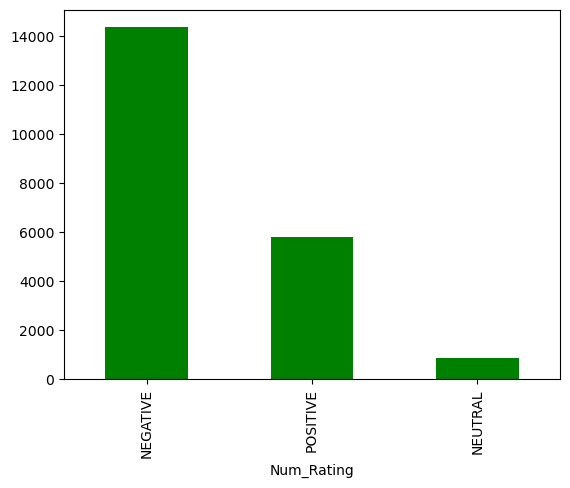

In [60]:
data_ = TextProcessing('Amazon_Reviews.csv')
data_.Graph()

In [177]:
data=data_.processing()
#data['df']=data['Num_Rating'].map({'POSITIVE':1, 'NEGATIVE':0})
#data.head(5)
X,y= data['Review Text'].values ,data['Num_Rating'].values
Xtrain, Xtest,ytrain,ytest = train_test_split(X, y, test_size=0.1,random_state=42, shuffle=True)

'word'

In [141]:
#Model train

pipe=Pipeline([('scalar', CountVectorizer()), ('clf', LogisticRegression())])

param_grid= [
            {'clf': [KNeighborsClassifier()]},
            {'clf': [MultinomialNB()]},
            {'clf': [LogisticRegression(max_iter=1000)]}
            ]
grid= GridSearchCV(estimator=pipe, 
                   param_grid=param_grid,           
                   cv=5,
                   #scoring= make_scorer(f1_score, average='macro'),
                   refit = True
                      )
grid.fit(Xtrain, ytrain)

voting= VotingClassifier(estimators=[('knn' , [CountVectorizer(), KNeighborsClassifier()]), 
                                    ('mnb', [CountVectorizer(), MultinomialNB()]), 
                                     ('lgt3', [CountVectorizer(),LogisticRegression()])],
                                      voting='soft')
voting.fit_transform(Xtrain,ytrain)


In [170]:
y_pred=grid.predict(Xtest)
score=accuracy_score(y_pred, ytest)
score

0.8817663817663818

### Model Deployment

In [171]:
with open('model', 'rb') as f:
    f= pickle.dumps(voting)